In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/ab_testing/fast_food.csv')
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [3]:
print(f"""
Rows           : {df.shape[0]}
Columns        : {df.shape[1]}

Features       :
{df.columns.tolist()}

Missing values : {df.isnull().sum().sum()}

Unique values  :
{df.nunique()}
""")


Rows           : 548
Columns        : 7

Features       :
['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands']

Missing values : 0

Unique values  :
MarketID             10
MarketSize            3
LocationID          137
AgeOfStore           25
Promotion             3
week                  4
SalesInThousands    517
dtype: int64



In [4]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


## Exploratory Data Analysis (EDA)

### Sales Distribution by Promotion

In [6]:
import plotly.express as px

In [7]:
fig = px.box(
    df,
    x="Promotion",
    y="SalesInThousands",
    color="Promotion",
    title="Sales Distribution by Promotion"
)
fig.show()

### Average Sales per Promotion

In [8]:
promo_avg = (
    df.groupby("Promotion")["SalesInThousands"]
    .mean()
    .reset_index()
)

fig = px.bar(
    promo_avg,
    x="Promotion",
    y="SalesInThousands",
    text="SalesInThousands",
    title="Average Sales by Promotion"
)
fig.show()

### Sales Trend Over Time

In [10]:
weekly_sales = (
    df.groupby(["week", "Promotion"])["SalesInThousands"]
    .mean()
    .reset_index()
)
weekly_sales.head()

,week,Promotion,SalesInThousands
0,1,1,58.244419
1,1,2,47.730213
2,1,3,55.776170
3,2,1,56.929535
4,2,2,47.582553


In [11]:
fig = px.line(
    weekly_sales,
    x="week",
    y="SalesInThousands",
    color="Promotion",
    markers=True,
    title="Weekly Sales Trend by Promotion"
)
fig.show()

### Market Size Effect

In [12]:
fig = px.box(
    df,
    x="MarketSize",
    y="SalesInThousands",
    color="Promotion",
    title="Sales by Market Size and Promotion"
)
fig.show()

### Store Age Impact

In [13]:
fig = px.scatter(
    df,
    x="AgeOfStore",
    y="SalesInThousands",
    color="Promotion",
    trendline="ols",
    title="Sales vs Store Age"
)
fig.show()

## Statistical Testing

In [17]:
from scipy import stats

In [18]:
# better: aggregate per store first
store_level = (
    df.groupby(["LocationID", "Promotion"])["SalesInThousands"]
    .mean()
    .reset_index()
)

In [19]:
# Comparing Promotion 1 vs Promotion 2 in an A/B Test
t,p = stats.ttest_ind(
    store_level[store_level["Promotion"] == 1]["SalesInThousands"],
    store_level[store_level["Promotion"] == 2]["SalesInThousands"],
    equal_var=False
)

print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

T-statistic: 3.3321, P-value: 0.0013


In [ ]:
# The p-value is less than 0.05, so we reject the null hypothesis and conclude that 
# there is a statistically significant difference in sales between Promotion 1 and Promotion 2.

In [20]:
# Comparing Promotion 1 vs Promotion 3
t, p = stats.ttest_ind(
    df.loc[df['Promotion'] == 1, 'SalesInThousands'].values, 
    df.loc[df['Promotion'] == 3, 'SalesInThousands'].values, 
    equal_var=False)

print("t-value = " +str(t))
print("p-value = " +str(p))

t-value = 1.5560224307758634
p-value = 0.12059147742229487


In [ ]:
# The p-value is greater than 0.05, so we fail to reject the null hypothesis and conclude that 
# there is no statistically significant difference in sales between Promotion 1 and Promotion 3.

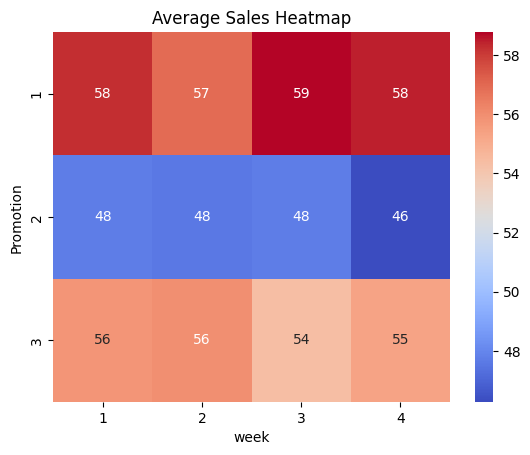

In [ ]:
# Heatmap (Aggregated Insights)

pivot = df.pivot_table(
    values="SalesInThousands",
    index="Promotion",
    columns="week",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Average Sales Heatmap")
plt.show()

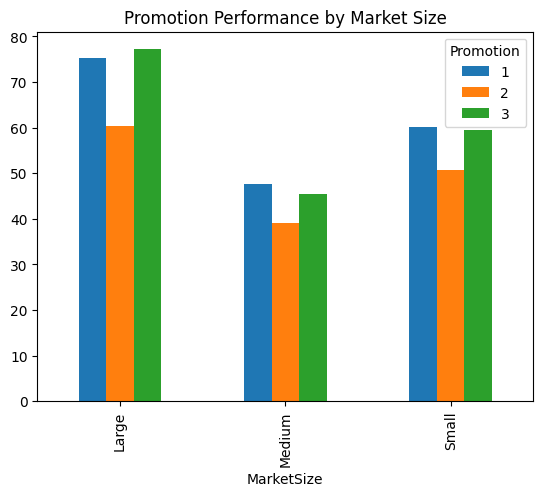

In [ ]:
# Market Size Performance Comparison (Stacked Bar)

market_pivot = df.pivot_table(
    values="SalesInThousands",
    index="MarketSize",
    columns="Promotion",
    aggfunc="mean"
)

market_pivot.plot(kind="bar")
plt.title("Promotion Performance by Market Size")
plt.show()